# digital_classifier_symbolic_arithmetic

In [1]:
print("hello world")

hello world


We have a bunch of images of numbers, but somehow we lost the knowledge behind how to read numbers. But thankfully someone kept a list of how to do addition and a record of how that addition was applied to our images of numbers.

How can we re-learn how to read the numbers based only on the ontology about the addition?

Real world example:

Here's one that sits close to home: **classifying bank transactions by category, using only the account's running balance as the label.**

### The setup

Banks store millions of transactions as short, messy text: `"AMZN MKTP US*2K3L9"`, `"POS DEBIT WALMART #4521"`, `"ACH TRANSFER - PAYROLL"`. You want a model that reads that text and tags each one with a category: *deposit, purchase, fee, transfer, withdrawal*. Hand-labeling millions of transactions is expensive, and category rules change over time.

But every statement already has something for free: **the running balance after each transaction**, which the bank computed and stored the moment the transaction posted. Nobody labeled it for you; it's a byproduct of normal banking.

### The relationship you already know

```
balance[t] = balance[t-1] + signed_amount(category[t])
```

Where the sign depends on the category: a deposit adds, a purchase or fee subtracts, a transfer could go either way depending on direction. That's your rule, exactly as fixed as `sum = d1 + d2`.

### The mapping to MNIST addition

| MNIST addition | Transaction categorization |
|---|---|
| Image A, Image B | Transaction text, amount |
| Hidden digit (0-9) | Hidden category (deposit, purchase, fee, …) |
| Sum label | The posted running balance |
| Rule: `sum = d1 + d2` | Rule: `balance[t] = balance[t-1] + signed_amount(category)` |
| CNN reads pixels → digit | Text model reads description → category |
| Hidden digit accuracy | Category accuracy, checked against a small hand-labeled sample |

### Why it works the same way

A balance of $0 change pins down the category hard (has to be something that nets to zero, or a sign error you can catch). A big round deposit pins down "payroll" or "transfer in" almost by itself. Those easy cases anchor the model the same way sums of 0 and 18 anchored the digits, and the model uses them to decode the ambiguous ones, like a $4.99 debit that could be a fee or a small purchase.

### Where it's a harder fit than MNIST addition

- **The rule has a weak spot**, the same way multiplication had one. Transfers can be signed either way, so the rule alone doesn't fully pin that category down. You'd need an extra constraint (transfers between the customer's own accounts net to zero across statements) the way we needed "digits are roughly uniform" for the unsupervised version.
- **Noise is real here**, unlike a clean toy dataset. Bank data has corrections, reversals, and timing lags between "posted" and "available" balances. You'd need some tolerance in the loss instead of expecting an exact match every time.
- **Reasoning shortcuts are a real risk.** A model could learn "big positive number → call it deposit" without actually reading the merchant text, since sign alone often nets out the balance. You'd check this the same way the hidden digit accuracy caught it: hold out a small hand-labeled set and see if the model's categories look sane, not just whether its balances reconcile.

This is a strong portfolio project for your situation specifically, because it's the exact "verify with a rule instead of labeling by hand" pattern that shows up in the regulated-data work you've already done, and you could build it entirely on synthetic or public transaction data without touching anything from your employer.

## Load MNIST digit images

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets

rng = np.random.default_rng(0)   # fixed seed so your results match mine

In [ ]:
digits = datasets.load_digits()
X = digits.data / 16.0            # 1,797 images, each 8x8 = 64 pixels, scaled 0 to 1
true_digit = digits.target        # the real digit for each image (hidden from training)

X_train, X_test, digit_train, digit_test = train_test_split(
    X, true_digit, test_size=0.3, random_state=0, stratify=true_digit)

# semantic
RULE = np.add.outer(np.arange(10), np.arange(10))   # RULE[a, b] = a + b
N_OUTCOMES = RULE.max() + 1                         # sums 0..18 -> 19 possible outcomes

def make_pairs(n_pairs, n_images):
    return rng.integers(0, n_images, size=(n_pairs, 2))   # each row: (index of A, index of B)

train_pairs = make_pairs(20000, len(X_train))
test_pairs = make_pairs(2000, len(X_test))

# The ONLY label we train on: the output of the rule.
train_label = RULE[digit_train[train_pairs[:, 0]], digit_train[train_pairs[:, 1]]]
test_label = RULE[digit_test[test_pairs[:, 0]], digit_test[test_pairs[:, 1]]]

In [ ]:
# example of an image
X[1]

array([0.    , 0.    , 0.    , 0.75  , 0.8125, 0.3125, 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.6875, 1.    , 0.5625, 0.    , 0.    ,
       0.    , 0.    , 0.1875, 0.9375, 1.    , 0.375 , 0.    , 0.    ,
       0.    , 0.4375, 0.9375, 1.    , 1.    , 0.125 , 0.    , 0.    ,
       0.    , 0.    , 0.0625, 1.    , 1.    , 0.1875, 0.    , 0.    ,
       0.    , 0.    , 0.0625, 1.    , 1.    , 0.375 , 0.    , 0.    ,
       0.    , 0.    , 0.0625, 1.    , 1.    , 0.375 , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.6875, 1.    , 0.625 , 0.    , 0.    ])

In [9]:
X_train[1]

array([0.    , 0.    , 0.    , 0.625 , 0.375 , 0.    , 0.625 , 0.875 ,
       0.    , 0.    , 0.4375, 0.9375, 0.125 , 0.4375, 0.875 , 0.0625,
       0.    , 0.    , 0.9375, 0.5625, 0.0625, 0.9375, 0.75  , 0.125 ,
       0.    , 0.25  , 1.    , 0.625 , 0.6875, 1.    , 0.75  , 0.0625,
       0.    , 0.125 , 1.    , 1.    , 1.    , 0.5625, 0.    , 0.    ,
       0.    , 0.    , 0.3125, 0.75  , 0.625 , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.8125, 0.3125, 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.9375, 0.1875, 0.    , 0.    , 0.    ])

In [10]:
digit_train[1]

np.int64(4)

In [11]:
train_pairs[1]

array([642, 339])

In [ ]:
print(
    digit_train[642],
    digit_train[339]
)

6 7


In [12]:
train_label[1]

np.int64(13)

In [24]:
RULE

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
       [ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
       [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       [ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       [ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]])

create initial model

In [19]:
def new_model():
    return {"W": rng.normal(0, 0.01, size=(64, 10)), "b": np.zeros(10)}

def softmax(scores):
    scores = scores - scores.max(axis=1, keepdims=True)
    e = np.exp(scores)
    return e / e.sum(axis=1, keepdims=True)

def model_predict(model, x):
    """P(digit) for each image -> shape (n_images, 10)"""
    return softmax(x @ model["W"] + model["b"])

model = new_model()

In [23]:
# output is the probability predictions for each categorical (number) variable
model_predict(model, X_train[:1]).round(1)

array([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]])

symbologic semantics -- set of definitions for software to interpret the data -- also our total ontology because we are only working in this space

In [25]:
RULE

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
       [ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
       [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       [ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       [ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]])

In [26]:
def apply_rule(pA, pB):
    """Digit guesses -> outcome guesses, using the RULE table."""

    # the joint probability given the probability of each digit
    joint = pA[:, :, None] * pB[:, None, :]          # (n, 10, 10): chance of every pair (a, b)
    p_out = np.zeros((len(pA), N_OUTCOMES))
    
    for a in range(10):
        for b in range(10):
            p_out[:, RULE[a, b]] += joint[:, a, b]   # pair (a, b) lands on outcome RULE[a, b]
    
    return p_out

Image A:
- guesses
    - number 3 at 60%
    - umber 4 at 40%

Image B:
- guesses
    - number 4 at 70%
    - number 5 at 30%

look at all combinations of A+B
3+4=7, 3+5=8, 4+4=8, 4+5=8 and their joint probabilities

now we combine the joint probabilities based on the sum
7, (8, 8), 9

In [ ]:
pA = np.zeros((1, 10)); pA[0, 3], pA[0, 4] = 0.6, 0.4
pB = np.zeros((1, 10)); pB[0, 4], pB[0, 5] = 0.7, 0.3

print(apply_rule(pA, pB)[0, 7:10].round(2))   # -> [0.42 0.46 0.12] for 7,8,9

[0.42 0.46 0.12]


loss function

In [36]:
def loss_fn(p_out, label):
    return -np.log(p_out[np.arange(len(label)), label] + 1e-9).mean()

only keep options that are possible by our semantics / ontology

In [34]:
def what_would_explain(pA, pB, label):

    """Using the rule, which digits would have produced the label? -> target guesses."""

    joint = pA[:, :, None] * pB[:, None, :]
    fits = RULE[None, :, :] == label[:, None, None]  # True where pair (a, b) gives the label
    keep = joint * fits                               # zero out pairs that don't fit
    keep = keep / (keep.sum(axis=(1, 2), keepdims=True) + 1e-12)   # rescale to 100%
    
    return keep.sum(axis=2), keep.sum(axis=1)        # target for A, target for B

In [33]:
def train_step(model, xA, xB, label, lr=0.5):
    pA, pB = model_predict(model, xA), model_predict(model, xB)            # 1. guess
    p_out = apply_rule(pA, pB)                            # 2. apply the rule
    loss = loss_fn(p_out, label)                          # 3. score against the label
    targetA, targetB = what_would_explain(pA, pB, label)  # 4. work out the targets
    n = len(label)
    errA, errB = (pA - targetA) / n, (pB - targetB) / n   # how far off each guess is
    model["W"] -= lr * (xA.T @ errA + xB.T @ errB)        # 5. update weights
    model["b"] -= lr * (errA.sum(axis=0) + errB.sum(axis=0))
    return loss

In [37]:
batch_size, epochs, step = 32, 3, 0
history = []
for epoch in range(epochs):
    order = rng.permutation(len(train_pairs))
    for start in range(0, len(order), batch_size):
        batch = order[start:start + batch_size]
        iA, iB = train_pairs[batch, 0], train_pairs[batch, 1]
        loss = train_step(model, X_train[iA], X_train[iB], train_label[batch])
        step += 1
        if step % 50 == 0:
            # grading only: digit labels MEASURE progress, they never train
            acc = (model_predict(model, X_test).argmax(axis=1) == digit_test).mean()
            history.append((step, loss, acc))
    print(f"epoch {epoch + 1}: loss {loss:.3f}, hidden digit accuracy {acc:.1%}")

epoch 1: loss 0.239, hidden digit accuracy 96.9%
epoch 2: loss 0.140, hidden digit accuracy 97.2%
epoch 3: loss 0.103, hidden digit accuracy 97.4%


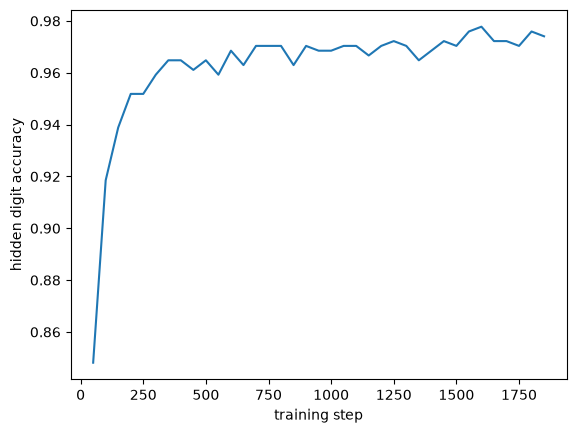

In [38]:
import matplotlib.pyplot as plt
steps, losses, accs = zip(*history)
plt.plot(steps, accs); plt.xlabel("training step"); plt.ylabel("hidden digit accuracy"); plt.show()

In [39]:
pA, pB = model_predict(model, X_test[test_pairs[:, 0]]), model_predict(model, X_test[test_pairs[:, 1]])
sum_acc = (apply_rule(pA, pB).argmax(axis=1) == test_label).mean()
digit_acc = (model_predict(model, X_test).argmax(axis=1) == digit_test).mean()
print(f"test sum accuracy:     {sum_acc:.1%}")
print(f"hidden digit accuracy: {digit_acc:.1%}")

from sklearn.linear_model import LogisticRegression   # same 1-layer model, but given every digit label
full = LogisticRegression(max_iter=2000).fit(X_train, digit_train)
print(f"same model WITH digit labels: {full.score(X_test, digit_test):.1%}")

test sum accuracy:     95.0%
hidden digit accuracy: 97.6%
same model WITH digit labels: 97.0%
